## Get M12

Inspirado en el codigo de
"06a_getm12_search.ipynb"




In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# == importar la libreria hecha ==
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), ".."))) # Añadir la ruta absoluta a 'mlpython/' al comienzo de sys.path

from lib import get_data_files, collect_all_rows
from lib.oracle import OracleExecutor , run_oracle
from lib.loss import compute_max_unitarity_eigenvalue


In [2]:
# ---- fixed params -----
#[mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m12_2]
mphi = 150
mA = 300
sin_ba = 1
tan_beta = 1e5
lambda6 = 0.01
lambda7 = 0.0
# ---- ------------ -----


lambdas_example = (0.5, 0.3, 0.2, -0.1,  0.05,  0.01,  0.02)
max_eig = compute_max_unitarity_eigenvalue(lambdas_example)
print(f"Max |eigenvalue| × 16π = {max_eig:.6f}")

#[mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m12_2]
# 
oracle = OracleExecutor()
def wrapper(m_12_2):
    """Calls the oracle run by assuming fixed parameters, except for m_12_2"""
    return oracle.run(params=[mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m_12_2])

def wrapper2(m_12_2):
    """Calls the oracle run by assuming fixed parameters, except for m_12_2"""
    return run_oracle(params=[mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m_12_2])

def f_scalar(m12):
    # Ensure m12 is a Python float (not array)
    m12_val = float(np.atleast_1d(m12))
    out_dict = wrapper2(m12_val)
    return np.abs((out_dict["lambda1"])   )

Max |eigenvalue| × 16π = 15.079645


In [3]:
df = pd.read_csv("../../dihiggs/results_2/out_mphi130.0-300.0_Nmphi20_m120.0-5.0_Nm1210000000000_mA300.0_sba1.0_tanb10000.0_l60.1_l70.0.csv")
print(df.columns)
df.head()

Index(['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba',
       'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok',
       'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga',
       'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1',
       'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5'],
      dtype='object')


,m_phi,mA,alpha,beta,lambda6,lambda7,m12,sin_ba,tan_beta,positivity_ok,...,width_hh,total_width,br_gaga,lam1,computed_lam1,lam2,computed_lam2,lam3,lam4,lam5
0,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689908,1.0,10000.0,1.0,...,0.0,7.099800e-11,0.449341,9.816096,12.524753,0.257734,0.258196,2.669307,-1.205802,-1.205802
1,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689908,1.0,10000.0,1.0,...,0.0,7.099400e-11,0.449315,9.757606,12.466158,0.257734,0.258196,2.669307,-1.205802,-1.205802
2,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689908,1.0,10000.0,1.0,...,0.0,7.098900e-11,0.449289,9.699116,12.407563,0.257734,0.258196,2.669307,-1.205802,-1.205802
3,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689908,1.0,10000.0,1.0,...,0.0,7.098500e-11,0.449263,9.640626,12.348968,0.257734,0.258196,2.669307,-1.205802,-1.205802
4,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689908,1.0,10000.0,1.0,...,0.0,7.098100e-11,0.449237,9.582136,12.290373,0.257734,0.258196,2.669307,-1.205802,-1.205802


In [4]:
df.loc[:,["lam1","lam2","lam3","lam4","lam5"]]

,lam1,lam2,lam3,lam4,lam5
0,9.816096,0.257734,2.669307,-1.205802,-1.205802
1,9.757606,0.257734,2.669307,-1.205802,-1.205802
2,9.699116,0.257734,2.669307,-1.205802,-1.205802
3,9.640626,0.257734,2.669307,-1.205802,-1.205802
4,9.582136,0.257734,2.669307,-1.205802,-1.205802
...,...,...,...,...,...
4713,-14.964044,0.257734,1.637755,-0.690026,-0.690026
4714,-15.022534,0.257734,1.637755,-0.690026,-0.690026
4715,-15.081024,0.257734,1.637755,-0.690026,-0.690026
4716,-15.139514,0.257734,1.637755,-0.690026,-0.690026


In [5]:
import concurrent.futures

def compute_row(row):
	return compute_max_unitarity_eigenvalue((row['lam1'], row['lam2'], row['lam3'],row['lam4'], row['lam5'], row["lambda6"], row["lambda7"]))

with concurrent.futures.ThreadPoolExecutor() as executor:
	results = list(executor.map(compute_row, [row for _, row in df.iterrows()]))

# results is a list with the output of compute for each row

In [6]:
df["max_unitarity_eigenvalue"] = results 

In [7]:
df.columns

Index(['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba',
       'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok',
       'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga',
       'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1',
       'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5',
       'max_unitarity_eigenvalue'],
      dtype='object')

In [8]:
((df["positivity_ok"]==1.0) & (df["perturbativity_ok"]==1.0) & (df["unitarity_ok"]==1.0)).sum()

np.int64(777)

In [9]:
from scipy.optimize import curve_fit

# Filter valid points
valid_mask = (df["positivity_ok"]==1.0) & (df["perturbativity_ok"]==1.0) & (df["unitarity_ok"]==1.0)
valid_df = df[valid_mask]

# Quadratic function: m_12 = a * m_phi^2 + b * m_phi + c
def quadratic(m_phi, a, b, c):
    return a * m_phi**2 + b * m_phi + c

# Fit the quadratic function to valid points
popt, pcov = curve_fit(quadratic, valid_df["m_phi"], valid_df["m12"])

# popt contains [a, b, c]
def m12_func(m_phi):
    a, b, c = popt
    return a * m_phi**2 + b * m_phi + c

print(f"Quadratic fit coefficients: a={popt[0]}, b={popt[1]}, c={popt[2]}")

Quadratic fit coefficients: a=0.00010000000851113562, b=-3.3348298850757027e-09, c=-9.076543497111311e-05


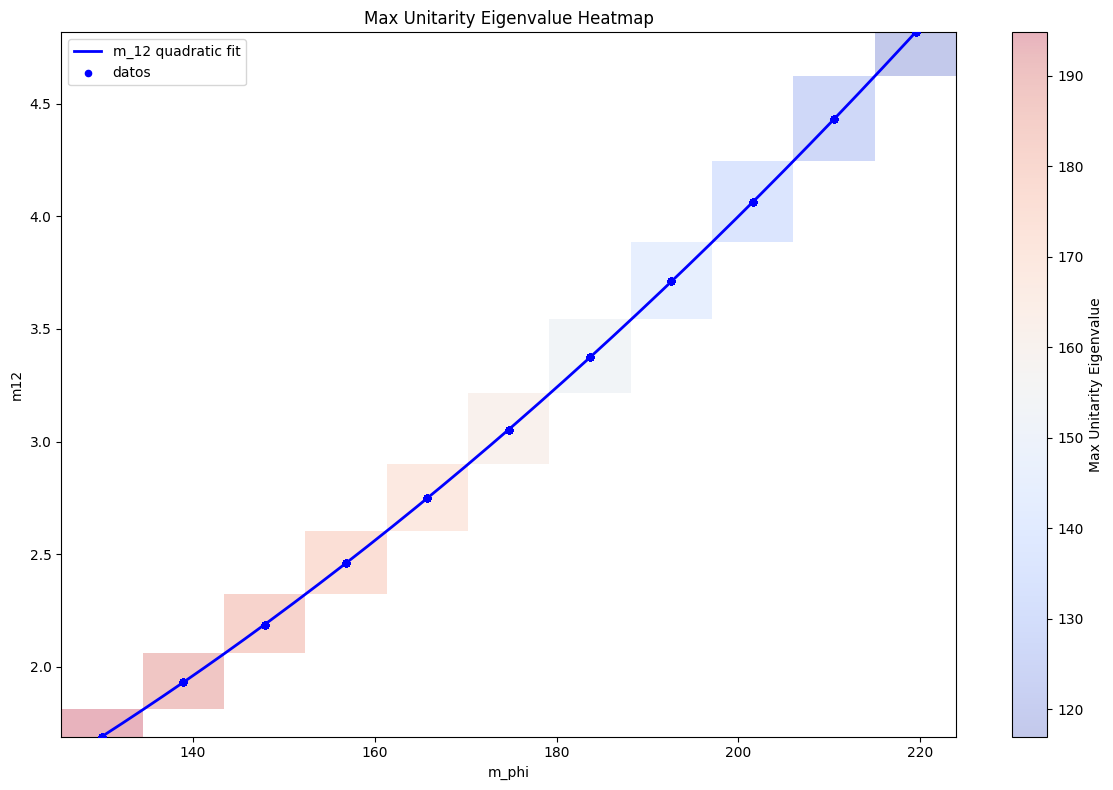

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 3) Pivotar sin duplicados
heatmap_data = df.pivot(
    index='m12', 
    columns='m_phi', 
    values='max_unitarity_eigenvalue'
)

# 1) Extrae coordenadas reales
x_vals = heatmap_data.columns.astype(float).values
y_vals = heatmap_data.index.astype(float).values
Z      = heatmap_data.values

# 2) Crea la malla
X, Y = np.meshgrid(x_vals, y_vals)

fig, ax = plt.subplots(figsize=(12, 8))

# 3) Dibuja mapa de calor alineado
pcm = ax.pcolormesh(
    X, Y, Z,
    cmap="coolwarm",
    shading="auto",
    alpha=0.3,
    zorder=1
)
fig.colorbar(pcm, ax=ax, label="Max Unitarity Eigenvalue")

# 4) Dibuja curva de ajuste y puntos
m_phi_vals = np.linspace(df["m_phi"].min(), df["m_phi"].max(), 200)
m12_vals   = m12_func(m_phi_vals)
ax.plot(
    m_phi_vals,
    m12_vals,
    label="m_12 quadratic fit",
    color="blue",
    linewidth=2,
    zorder=2
)
ax.scatter(
    df["m_phi"],
    df["m12"],
    color="blue",
    s=20,
    zorder=3,
    label="datos"
)

ax.set_xlabel("m_phi")
ax.set_ylabel("m12")
ax.set_title("Max Unitarity Eigenvalue Heatmap")
ax.legend()
plt.tight_layout()
plt.show()



# Do a plot of Construct Graph
If you have enought physical points

In [11]:
# --- Paso 1: Crear un DataFrame de ejemplo con puntos físicos ---
# Columnas: m_phi, m12_2, positivity_ok, unitarity_ok, perturbativity_ok


# --- Paso 2: Filtrar solo los puntos físicos donde positivity_ok, unitarity_ok y perturbativity_ok == 1 ---
df_physical = df[
    (df['positivity_ok'] == 1) &
    (df['unitarity_ok']  == 1) &
    (df['perturbativity_ok'] == 1)
].reset_index(drop=True)


print(len(df_physical))
df_physical.head()



777


,m_phi,mA,alpha,beta,lambda6,lambda7,m12,sin_ba,tan_beta,positivity_ok,...,total_width,br_gaga,lam1,computed_lam1,lam2,computed_lam2,lam3,lam4,lam5,max_unitarity_eigenvalue
0,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689909,1.0,10000.0,1.0,...,7.059000e-11,0.446795,4.14256,6.841038,0.257734,0.258196,2.669307,-1.205802,-1.205802,194.784233
1,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689909,1.0,10000.0,1.0,...,7.058600e-11,0.446769,4.08407,6.782443,0.257734,0.258196,2.669307,-1.205802,-1.205802,194.784233
2,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689909,1.0,10000.0,1.0,...,7.058200e-11,0.446742,4.02558,6.723848,0.257734,0.258196,2.669307,-1.205802,-1.205802,194.784233
3,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689909,1.0,10000.0,1.0,...,7.057800e-11,0.446716,3.96709,6.665253,0.257734,0.258196,2.669307,-1.205802,-1.205802,194.784233
4,130.0,300.0,-0.0001,1.570696,0.1,0.0,1.689909,1.0,10000.0,1.0,...,7.057400e-11,0.446690,3.90860,6.606658,0.257734,0.258196,2.669307,-1.205802,-1.205802,194.784233


In [12]:
df_physical.columns

Index(['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba',
       'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok',
       'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga',
       'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1',
       'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5',
       'max_unitarity_eigenvalue'],
      dtype='object')

In [13]:
from lib import get_branching_format_from_df, plot_branchings, plot_branchings_and_lifetime


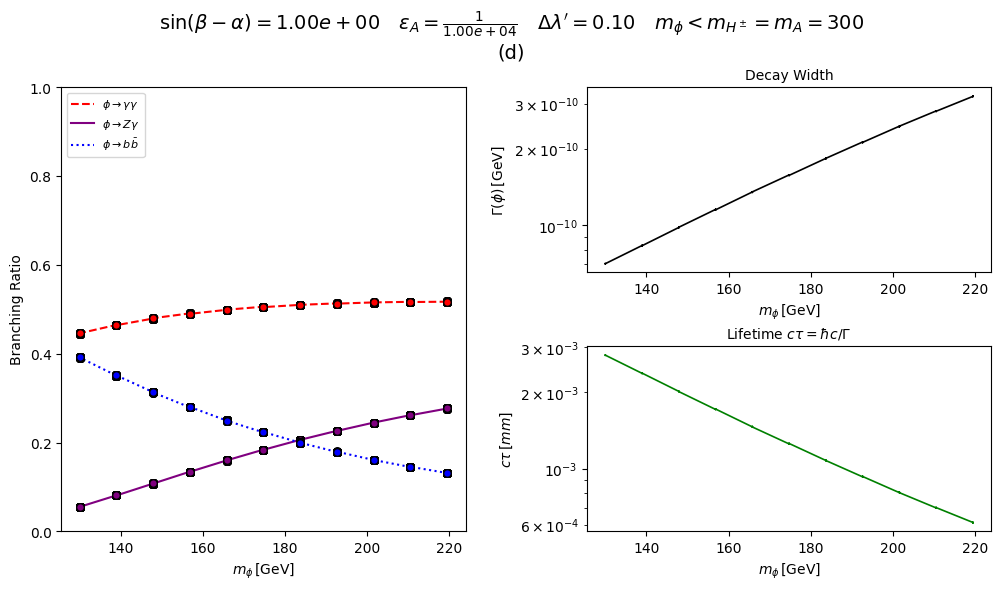

In [ ]:
results = get_branching_format_from_df(df_physical)
plot_branchings_and_lifetime(results, subplot_tag="")